# **Introduction**

**In this notebook I've been dealing with taitanic data while learning data analysis.**

This Dataset contains the information about Titanic ship and included 891Rows and 12 columns.In this notebook I try to find the best ML model to predict which passengers survived the Titanic shipwreck.    Variable Notes:

pclass: A proxy for socio-economic status (SES)(Ticket class) 1 = 1st, 2 = 2nd, 3 = 3rd

1st = Upper

2nd = Middle

3rd = Lower

age:Age in years

Sibsp: The dataset defines family relations in this way...(number of siblings / spouses aboard the Titanic)

Sibling = brother, sister, stepbrother, stepsister

Spouse = husband, wife (mistresses and fiancés were ignored)

Parch: The dataset defines family relations in this way...(number of parents / children aboard the Titanic)

Parent = mother, father

Child = daughter, son, stepdaughter, stepson

Some children travelled only with a nanny, therefore parch=0 for them.

Survival:0 = No, 1 = Yes

Sex:Sex

Ticket:Ticket number

Fare:Passenger fare

Cabin:Cabin number

Embarked:Port of Embarkation(C = Cherbourg, Q = Queenstown, S = Southampton)

In [1]:
import numpy as np#import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
train=pd.read_csv("../input/c/titanic/train.csv")#import the dataset
test=pd.read_csv("../input/c/titanic/train.csv")

In [3]:

#store the passengerid of test data
passenger_id=test["PassengerId"]

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#set the index as passengerid
train.set_index(["PassengerId"],inplace=True)
test.set_index(["PassengerId"],inplace=True)
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Checking the missing data**:
### The real-world data often has a lot of missing values. The cause of missing values can be data corruption or failure to record data. The handling of missing data is very important during the preprocessing of the dataset as many machine learning algorithms do not support missing values. Now I want to identify the rows with the most number of missing values and drop or transform them.

In [5]:
train.isnull().sum()#show the missing datas

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [6]:
100*(train.isnull().sum()/len(train))
def missing_values_percent(train):#we can use this function in all dataframes.
    nan_percent=100*(train.isnull().sum()/len(train))
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return(nan_percent)

nan_percent=missing_values_percent(train)
nan_percent


Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

In [7]:
#deciding about age coloumn which have almost 19% missing datas.
#Imputer age coloumn
from sklearn.impute import SimpleImputer
#train data             
Imp=SimpleImputer(strategy='median')
new_train=Imp.fit_transform(train.Age.values.reshape(-1,1))
train['Age2'] = new_train

#test data
new_test=Imp.fit_transform(test.Age.values.reshape(-1,1))
test['Age2'] = new_test


train.drop('Age',axis=1,inplace=True)
test.drop('Age',axis=1,inplace=True)


train.head()

,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age2
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,NaN,S,22.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C85,C,38.0
3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,C123,S,35.0
5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,NaN,S,35.0


In [8]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
Age2          0
dtype: int64

In [9]:
train["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [10]:
#So we can replace missing datas in Embarked with s
train["Embarked"].fillna("s",inplace=True)

In [11]:
#cabin has 687 missing datas so we can get rid of it by dropping this feature.
train.drop("Cabin",axis=1,inplace=True)

In [12]:
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
Age2        0
dtype: int64

### **Now we have no missing data**

# **Exploratory Data Analysis**

In [13]:
train["Survived"].value_counts(normalize=True)#How many passengers survived?

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [14]:
def bar_chart_stacked(dataset,feature,stacked=True):
  survived=train[train["Survived"]==1][feature].value_counts()
  dead=train[train["Survived"]==0][feature].value_counts()   
  df_survived_dead=pd.DataFrame([survived,dead])  
  df_survived_dead.index=["passengers survived","passengers died"]   
  df_survived_dead.plot(kind="bar",stacked=stacked,figsize=(8,5))
                              

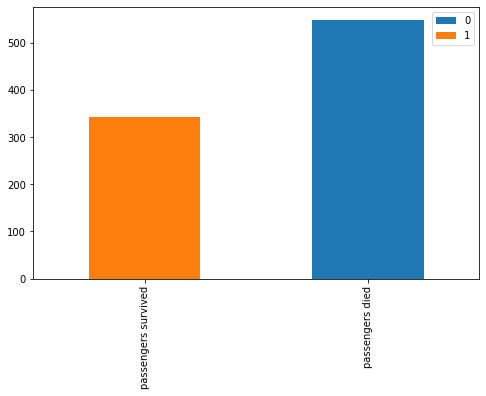

In [15]:
bar_chart_stacked(train,"Survived")

### As expected the majority of passengers in the training data died. Only 38% survived the disaster. So the training data suffers from data imbalance.

In [16]:
train["Sex"].value_counts().to_frame()#passengers count on gender

,Sex
male,577
female,314


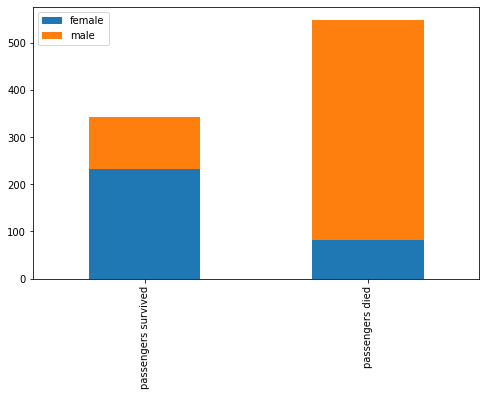

In [17]:
bar_chart_stacked(train,"Sex")#compare the survived  and dead passengers counts on gender

### We can see that even though the majority of passenger were men, the majority of survivors were women. The key observation here is that the survival rate for female passengers is 4 times higher than the survival rate of male passengers.Maybe the women were rescued earlier or the man helped the women and they didnt have enough time to save themselves. 

In [18]:
train.groupby(["Pclass"])["Survived"].mean().to_frame()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


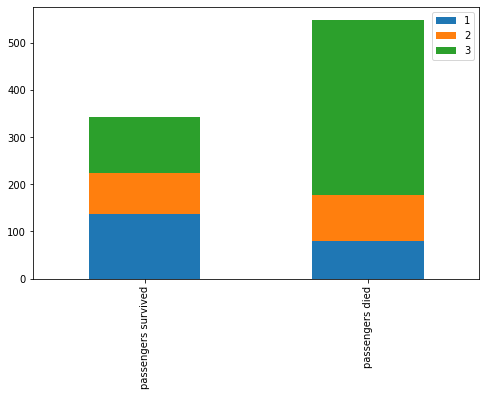

In [19]:
bar_chart_stacked(train,"Pclass")

### We see that 62% of passengers in class 1 were survived but this amount is reduced to 47% for class 2 and only 24% of passengers in class 3 were survived.On the other words the percentage of survived passengers in class 1 is 2 times bigger than the percentage of died passengers in this class.But in class 2 the percentage of survived people and died people is almost equal and for class 3 the percentage of died people is three times bigger than survived one.

In [20]:
def bar_chart_compare(dataset,feature1,feature2=None):
    plt.figure(figsize=(8,5))
    plt.title("survived rate by sex and pclass")
    g=sns.barplot(x=feature1,y="Survived",hue=feature2,data=dataset).set 

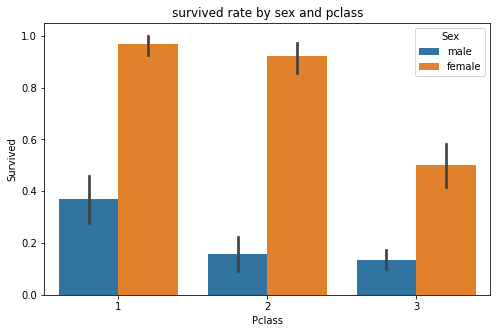

In [21]:
bar_chart_compare(train,"Pclass","Sex")

### We see that the number of men and women who were survived is decreasing according to class.In addition,men and women in class 1 had a significantly higher chance of survival if they bought class 1 tickets.

<AxesSubplot:xlabel='Age2', ylabel='Survived'>

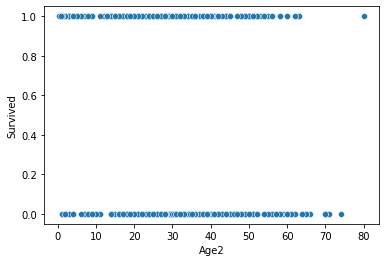

In [22]:
sns.scatterplot(data=train,x="Age2",y="Survived")

### As we see the passangers who were 1 to almost 57 years old,were survived but the paasengers who were above 60 years old mostly died.

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 61.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:title={'center':'survival swarmplot for fare and gender'}, xlabel='Sex', ylabel='Fare'>

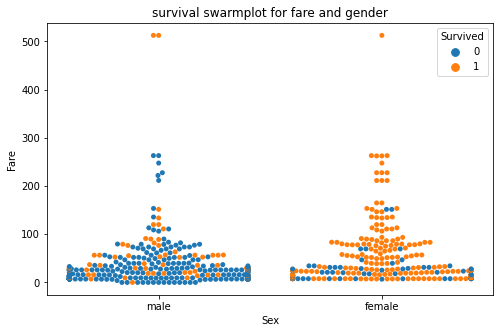

In [23]:
    plt.figure(figsize=(8,5))
    plt.title("survival swarmplot for fare and gender")
    sns.swarmplot(y="Fare",x="Sex",hue="Survived",data=train)

### Gender of all passengers with a fare above 500 dollar survived.The men who paid between 200 and 300 dollar died but the women paid between 200 and 300 dollar survived.

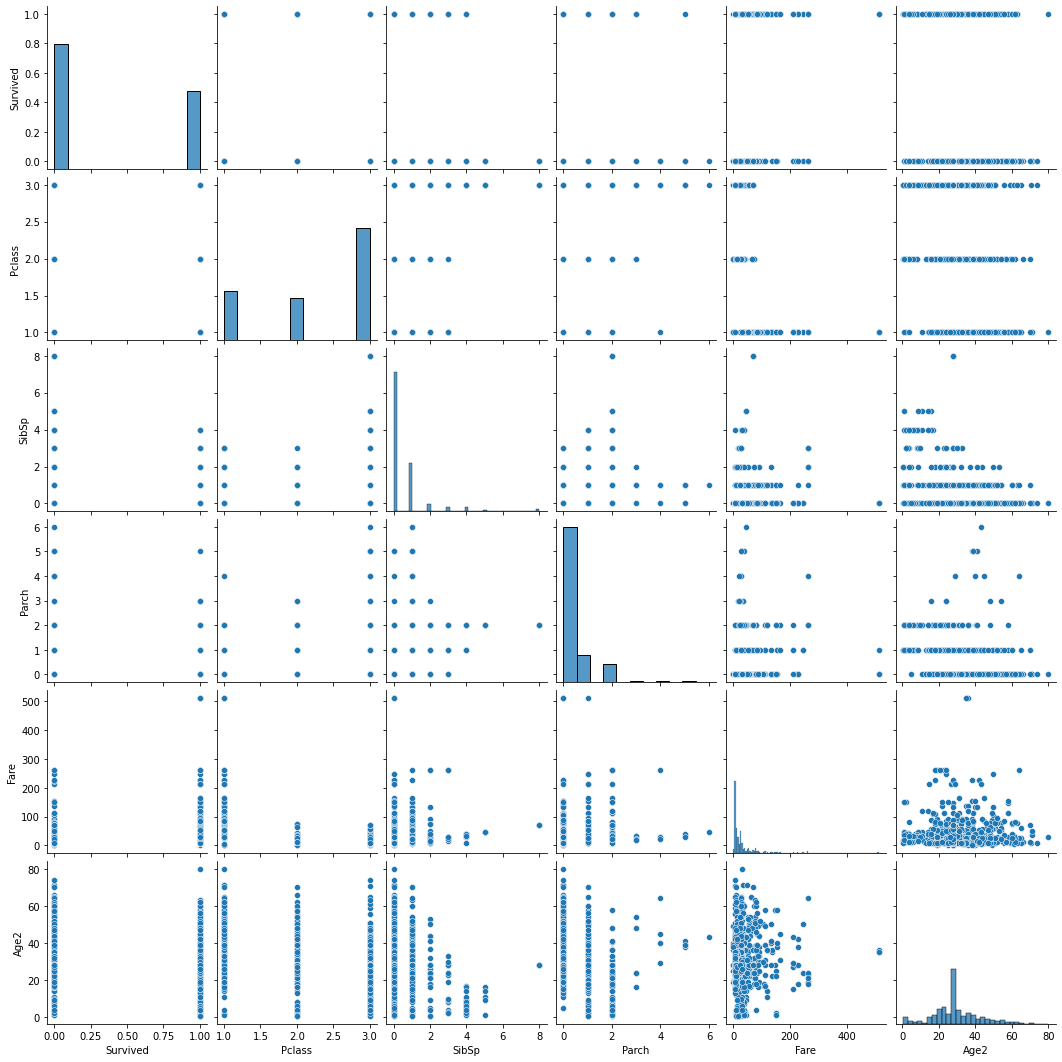

In [24]:
sns.pairplot(train)

<AxesSubplot:>

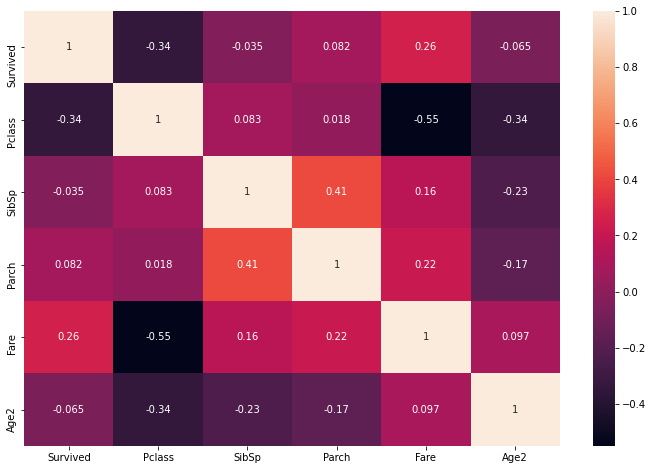

In [25]:
corr = train.corr()
plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True)

# **Feature Engineering**

## **Name feature**

In [26]:
train["Name"]

PassengerId
1                                Braund, Mr. Owen Harris
2      Cumings, Mrs. John Bradley (Florence Briggs Th...
3                                 Heikkinen, Miss. Laina
4           Futrelle, Mrs. Jacques Heath (Lily May Peel)
5                               Allen, Mr. William Henry
                             ...                        
887                                Montvila, Rev. Juozas
888                         Graham, Miss. Margaret Edith
889             Johnston, Miss. Catherine Helen "Carrie"
890                                Behr, Mr. Karl Howell
891                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [27]:
train['Title'] =train['Name'].apply(lambda x: x.split(', ')[1].split('. ')[0].strip())
test['Title'] =train['Name'].apply(lambda x: x.split(', ')[1].split('. ')[0].strip())
train["Title"].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

<AxesSubplot:xlabel='Title', ylabel='Survived'>

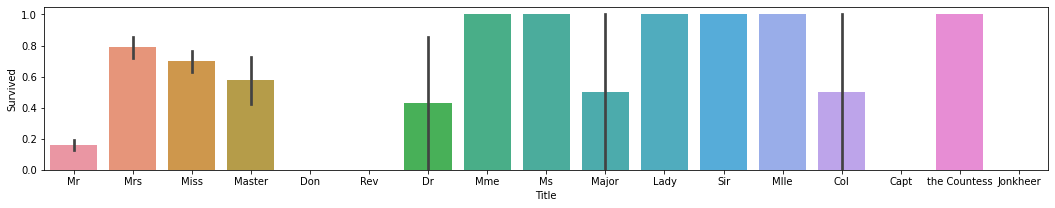

In [28]:
plt.figure(figsize=(18,3))
sns.barplot(data=train,x="Title",y="Survived")

### We see the titles which are women title have a high survival rate in comparison with men title.Master and Dr have a high survival rate, too even though both are male titles.but Mr have a low survival rate.

# **Family feature**

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
 9   Age2      891 non-null    float64
 10  Title     891 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 115.8+ KB


In [30]:
train["family_size"]=train["SibSp"]+train["Parch"]+1

In [31]:
def family_group(size):
    a=""
    if(size<=1):
        a="alone"
    elif(size<=4):
        a="small"
    else:
        a="large"
    return a

In [32]:
train["family_group"]=train["family_size"].map(family_group)
train["fare_per_person"]=train["Fare"]/train["family_size"]
train.head()

,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked,Age2,Title,family_size,family_group,fare_per_person
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,S,22.0,Mr,2,small,3.62500
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C,38.0,Mrs,2,small,35.64165
3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,S,26.0,Miss,1,alone,7.92500
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,S,35.0,Mrs,2,small,26.55000
5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,S,35.0,Mr,1,alone,8.05000


<AxesSubplot:xlabel='family_group', ylabel='Survived'>

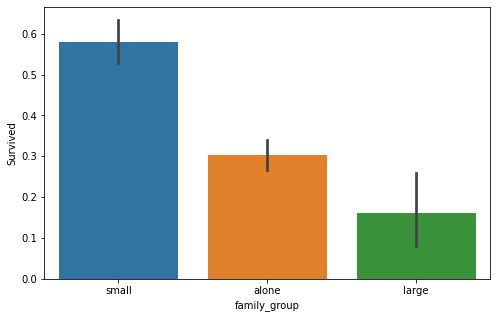

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=train,x="family_group",y="Survived")

### As we see small family survived more in comparison with alone and large family.on the other words the percentage of survived passenger for small family is three times bigger than large family and two times bigger than alone passenger.

In [34]:
train.drop(["Ticket"],axis=1,inplace=True)#This feature doesnt give us any useful infomation.

# **Encoding str to int**

In [35]:
train["Pclass"].apply(str)

PassengerId
1      3
2      1
3      3
4      1
5      3
      ..
887    2
888    1
889    3
890    1
891    3
Name: Pclass, Length: 891, dtype: object

In [36]:
#Divide dataframe to 2 parts(num and str)
train_num=train.select_dtypes(exclude="object")
train_obj=train.select_dtypes(include="object")

In [37]:
train_obj=pd.get_dummies(train_obj,drop_first=True)#use one-hot encoding to transform str to int and float
train_obj.shape

(891, 912)

In [38]:
Final_train=pd.concat([train_num,train_obj],axis=1)
Final_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Columns: 920 entries, Survived to family_group_small
dtypes: float64(3), int64(5), uint8(912)
memory usage: 888.5 KB


# **Logestic regression**

In [39]:
#Determine the feature and lable
X=Final_train.drop("Survived",axis=1)
y=Final_train["Survived"]

In [40]:
#Split the dataset to train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [41]:
from sklearn.preprocessing import StandardScaler#scaling the features
scaler= StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [44]:
accuracy_score(y_test, y_pred)

0.8022388059701493

In [45]:
confusion_matrix(y_test, y_pred)

array([[138,  16],
       [ 37,  77]])

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       154
           1       0.83      0.68      0.74       114

    accuracy                           0.80       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.80      0.80       268

